In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bmadushanirodrigo/fracture-multi-region-x-ray-data")

print("Path to dataset files:", path)

# Download latest version
path = kagglehub.dataset_download("tolgadincer/labeled-chest-xray-images")

print("Path to dataset files:", path)

# Download latest version
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")

print("Path to dataset files:", path)

100%|██████████| 481M/481M [00:03<00:00, 153MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/versions/2
Using Colab cache for faster access to the 'labeled-chest-xray-images' dataset.
Path to dataset files: /kaggle/input/labeled-chest-xray-images
Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.
Path to dataset files: /kaggle/input/brain-tumor-classification-mri


In [7]:
!ls /root/.cache/kagglehub/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/versions/2/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification

test  train  val


In [9]:
!ls /kaggle/input/labeled-chest-xray-images/chest_xray

test  train


In [10]:
!ls /kaggle/input/brain-tumor-classification-mri

Testing  Training


In [15]:
import os
import random
import numpy as np
import cv2

from pathlib import Path
from tqdm import tqdm
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [39]:
IMG_SIZE = 128
TARGET_PER_DATASET = 1000
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [40]:
def load_dataset_limited(base_path, label_name):
    data = []

    base_path = Path(base_path)

    if (base_path / "train").exists():
        base_path = base_path / "train"
    elif (base_path / "Training").exists():
        base_path = base_path / "Training"

    all_images = []

    # Collect all image paths from all classes
    for class_name in os.listdir(base_path):
        class_path = base_path / class_name

        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            all_images.append(class_path / img_name)

    # Shuffle globally
    random.shuffle(all_images)

    # Take only 1000
    selected_images = all_images[:TARGET_PER_DATASET]

    X = []
    y = []

    for img_path in tqdm(selected_images, desc=f"Loading {label_name}"):

        try:
            img = cv2.imread(str(img_path))
            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0

            X.append(img)
            y.append(label_name)

        except:
            continue

    return X, y

In [41]:
fracture_path = "/root/.cache/kagglehub/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/versions/2/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"

chest_path = "/kaggle/input/labeled-chest-xray-images/chest_xray"

brain_path = "/kaggle/input/brain-tumor-classification-mri"


X1, y1 = load_dataset_limited(fracture_path, "bone")
X2, y2 = load_dataset_limited(chest_path, "chest")
X3, y3 = load_dataset_limited(brain_path, "brain")

# Combine
X = np.array(X1 + X2 + X3)
y = np.array(y1 + y2 + y3)

print("Final Distribution:", Counter(y))
print("Shape:", X.shape)

Loading brain: 100%|██████████| 1000/1000 [00:03<00:00, 329.55it/s]


Final Distribution: Counter({np.str_('bone'): 1000, np.str_('chest'): 1000, np.str_('brain'): 1000})
Shape: (3000, 128, 128, 3)


In [42]:
idx = np.random.permutation(len(X))
X = X[idx]
y = y[idx]

In [43]:
encoder = LabelEncoder()
y_int = encoder.fit_transform(y)

num_classes = len(np.unique(y_int))

y_cat = tf.keras.utils.to_categorical(y_int)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.2,
    random_state=SEED,
    stratify=y_int
)

In [45]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,659 (10.49 MB)

 Trainable params: 2,749,699 (10.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [47]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.9554 - loss: 0.4452 - val_accuracy: 0.3450 - val_loss: 13.2297 - learning_rate: 0.0010
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9908 - loss: 0.0997 - val_accuracy: 0.3600 - val_loss: 10.7739 - learning_rate: 0.0010
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9892 - loss: 0.1568 - val_accuracy: 0.6517 - val_loss: 4.6464 - learning_rate: 0.0010
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9937 - loss: 0.0933 - val_accuracy: 0.9717 - val_loss: 0.2060 - learning_rate: 0.0010
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9883 - loss: 0.1146 - val_accuracy: 0.7500 - val_loss: 5.4716 - learning_rate: 0.0010
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9971 - loss: 0.0183 - val_accuracy: 0.9650 - val_loss: 0.5375 - learning_rate: 0.0010
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9950 - loss: 0.0456 - val_

In [53]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9967 - loss: 0.0314
Test Accuracy: 0.996666669845581


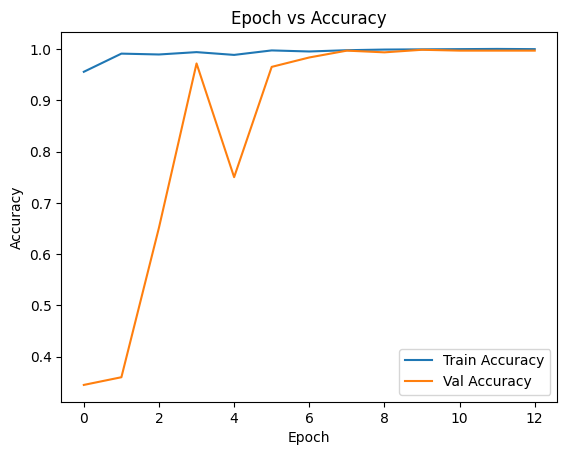

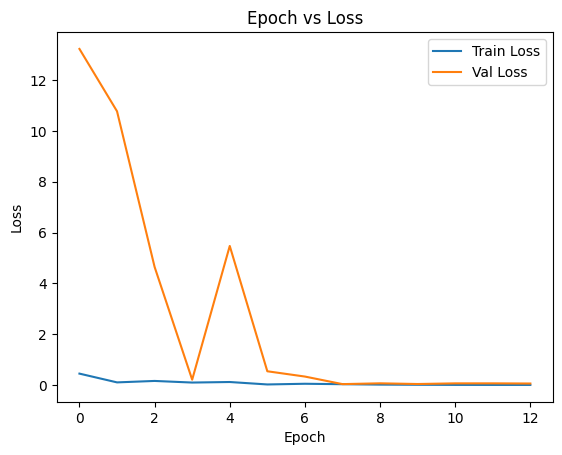

In [50]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Epoch vs Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Epoch vs Loss')
plt.legend()
plt.show()

In [51]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step


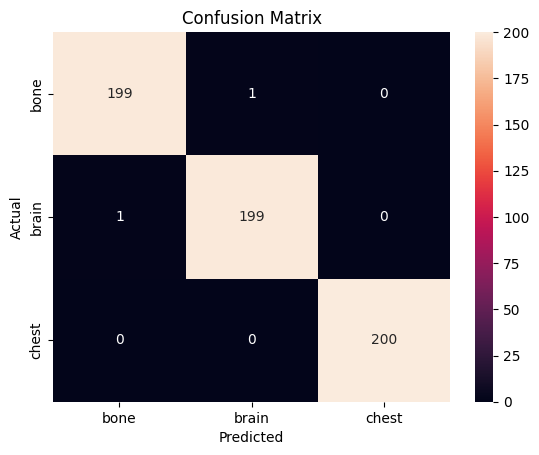

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [54]:
model.save("medical_3class_model.h5")